# Neural Network Classification

Neural network classification is a machine learning technique used to assign inputs to discrete categories or classes by learning decision boundaries from labeled data. It uses layers of interconnected neurons with nonlinear activation functions to model complex patterns and separations between classes that simpler classifiers may fail to capture. Neural network classification is commonly applied in tasks such as image and face recognition, spam detection, sentiment analysis, medical diagnosis, and fraud detection, where the goal is to determine the correct class or probability of each possible class for a given input.

- **Types :**
   - Binary Classification
   - Multiclass Classification
   - Multilabel Classification
---

# Input and Output Shapes

## Input Shape represented as a tensor in the form of :
```
Input_shape = [batch_size, height, width, color_channels]
```
- **batch_size :** 32 is a very common batch size.
- **height :** The height of the image in pixels.
- **width :** The width of the image in pixels.
- **color_channels :** If (`RGB`) then it is 3, if (`CYMK`) then it is 4.

## Output Shape represented as a tensor in the form of :
```
Output_Shape = [No. of classes we are classifying]
```

---

# Anatomy and Architecture

| Hyperparameter               | Binary Classification                                                                                        | Multiclass Classification                                                                                                                                 |
| ---------------------------- | ------------------------------------------------------------------------------------------------------------ |-----------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Input layer shape**        | Same as number of features (e.g. 5 for age, sex, height, weight, smoking status in heart disease prediction) | Same as binary classification                                                                                                                             |
| **Hidden layer(s)**          | Problem specific, minimum = 1, maximum = unlimited                                                           | Same as binary classification                                                                                                                             |
| **Neurons per hidden layer** | Problem specific, generally 10 to 100                                                                        | Same as binary classification                                                                                                                             |
| **Output layer shape**       | 1 (one class or the other)                                                                                   | 1 per class (e.g. 3 for food, person, or dog photo)                                                                                                       |
| **Hidden activation**        | Usually **ReLU** (rectified linear unit)                                                                     | Same as binary classification                                                                                                                             |
| **Output activation**        | **Sigmoid**                                                                                                  | **Softmax**                                                                                                                                               |
| **Loss function**            | Cross entropy (**BinaryCrossentropy** in TensorFlow)                                                         | Cross entropy (**CategoricalCrossentropy** in TensorFlow for one hot encoded labels, **SparseCategoricalCrossentropy** in TensorFlow for numeric labels ) |
| **Optimizer**                | **SGD** (stochastic gradient descent), **Adam**                                                              | Same as binary classification                                                                                                                             |


## Classification Metrics


| Metric Name        | Metric Formula                                                                 | Code                                                                 | When to use                                                                 |
|--------------------|----------------------------------------------------------------------------------|----------------------------------------------------------------------|------------------------------------------------------------------------------|
| Accuracy           | **Accuracy** = (tp + tn) / (tp + tn + fp + fn)                                  | `tf.keras.metrics.Accuracy()`<br>or<br>`sklearn.metrics.accuracy_score()` | Default metric for classification problems. Not the best for imbalanced classes. |
| Precision          | **Precision** = tp / (tp + fp)                                                   | `tf.keras.metrics.Precision()`<br>or<br>`sklearn.metrics.precision_score()` | Higher precision leads to fewer false positives.                             |
| Recall             | **Recall** = tp / (tp + fn)                                                      | `tf.keras.metrics.Recall()`<br>or<br>`sklearn.metrics.recall_score()` | Higher recall leads to fewer false negatives.                                 |
| F1-score           | **F1-score** = 2 · (precision · recall) / (precision + recall)                  | `sklearn.metrics.f1_score()`                                         | Combination of precision and recall; good overall metric for classification. |
| Confusion Matrix   | NA                                                                               | Custom function<br>or<br>`sklearn.metrics.confusion_matrix()`        | Used to compare predictions with true labels and analyze model confusion.    |


## Classification Loss Functions

### `binary_crossentropy`
**Definition:**
Used for **binary classification** (two classes, e.g., 0 or 1).
It measures the difference between the predicted probability and the true label.

**Formula:**
$L = -[y \log(p) + (1 - y)\log(1 - p)]$

**When to use:**
- Binary classification problems
- Output layer uses `sigmoid` activation
**Examples:** Spam detection, disease prediction (yes/no)


### `categorical_crossentropy`
**Definition:**
Used for **multi-class classification** when labels are **one-hot encoded** (e.g., [1, 0, 0]).

**Formula:**
$L = -\sum y_i \log(p_i)$

**When to use:**
- Multi-class problems
- Output layer uses `softmax` activation
**Examples:** Handwritten digit recognition (0–9), image classification


### `sparse_categorical_crossentropy`
**Definition:**
Same as `categorical_crossentropy`, but labels are **integer encoded** instead of one-hot vectors.

**When to use:**
- Multi-class problems
- When labels are integers (e.g., [0, 1, 2])
- Output layer uses `softmax` activation
**Examples:** Text classification, multi-class sentiment analysis


### `hinge`
**Definition:**
Used in **Support Vector Machine (SVM)**–style classification.
Encourages a margin between classes.

**Formula:**
$L = \max(0, 1 - y \cdot \hat{y})$

**When to use:**
- Binary classification with labels in {-1, +1}
- When using linear classifiers or SVMs


### `squared_hinge`
**Definition:**
Similar to hinge loss but penalizes larger errors more strongly by squaring them.

**Formula:**
$L = [\max(0, 1 - y \cdot \hat{y})]^2$

**When to use:**
- Same as hinge, but smoother gradient for optimization
- Often performs slightly better in neural networks than raw hinge loss


### `kullback_leibler_divergence` (KL Divergence)
**Definition:**
Measures how one probability distribution diverges from another.
Used when the output is a **probability distribution**.

**Formula:**
$L = \sum y_i \log\left(\frac{y_i}{p_i}\right)$

**When to use:**
- Comparing predicted distributions to target distributions
- Probabilistic models, autoencoders, variational inference
**Examples:** Variational Autoencoders (VAE)

---


## Workflow:
```
Build a model -> fit it -> evaluate it -> improve it -> fit it -> evaluate it -> improve it...
```


## Creating Data

In [1]:
import random

import pylab as pl
import tensorflow as tf
from sklearn.datasets import make_circles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# no. of samples
n_samples = 1000

# create circles
x, y = make_circles(n_samples=n_samples, noise=0.03 ,random_state=42)

2026-01-20 01:43:02.722926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768866182.807350   77775 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768866182.831936   77775 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768866182.935603   77775 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768866182.935650   77775 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768866182.935654   77775 computation_placer.cc:177] computation placer alr

## Splitting Data

In [2]:
x_train, x_test = x[:800], x[800:]
y_train, y_test = y[:800], y[800:]

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((800, 2), (800,), (200, 2), (200,))

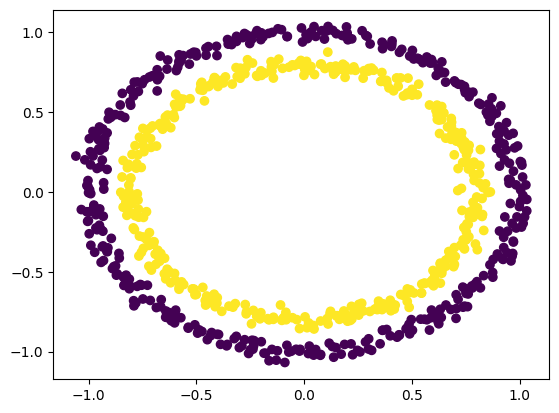

In [3]:
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train)
plt.show()

## Creating a model

In [4]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="relu"), # Hidden Layer |
    tf.keras.layers.Dense(10, activation="relu"), # -------------|
    tf.keras.layers.Dense(1, activation="sigmoid") # output Layer
])

## Compile a model

In [5]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

I0000 00:00:1768866193.573631   77775 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Model Summary

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Fitting a model

In [7]:
history = model.fit(x_train, y_train, epochs=100)

Epoch 1/100


I0000 00:00:1768866196.549272   77945 service.cc:152] XLA service 0x783730008a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768866196.549553   77945 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-01-20 01:43:16.617306: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768866197.103606   77945 cuda_dnn.cc:529] Loaded cuDNN version 91400


23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4989 - loss: 0.7135

I0000 00:00:1768866199.078079   77945 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4963 - loss: 0.7116
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4700 - loss: 0.7030
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4563 - loss: 0.6986
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4762 - loss: 0.6960
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4613 - loss: 0.6941
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4875 - loss: 0.6926
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4963 - loss: 0.6913
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4975 - loss: 0.6900
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5038 - loss: 0.6887
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5163 - loss: 0.6874
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5437 - loss: 0.6861
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5475 - l

## Evaluating a model

In [8]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Loss: {loss}, Accuracy: {(accuracy*100):.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 1.0000 - loss: 0.0436
Loss: 0.043627794831991196, Accuracy: 100.00%


## Visualizing Decision Boundary

In [9]:
def plot_decision_boundary(model, x, y):
    """
    Plot the decision boundary created by a model predicting on x.
    """
    # define the axis boundaries
    x_min, x_max = x[:, 0].min() - 0.1, x[:, 0].max() + 0.1
    y_min, y_max = x[:, 1].min() - 0.1, x[:, 1].max() + 0.1

    # create a grid of points
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    x_in = np.c_[xx.ravel(), yy.ravel()]

    # make predictions (suppress verbose output)
    y_pred = model.predict(x_in, verbose=0)

    # handle multiclass vs binary and reshape to grid
    if y_pred.ndim == 2 and y_pred.shape[1] > 1:
        # multiclass probabilities -> class indices
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        # binary -> probabilities or logits -> round after squeeze
        y_pred = np.round(y_pred.squeeze()).reshape(xx.shape)

    # plot the decision boundary and data points
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(x[:, 0], x[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu, edgecolor='k')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()

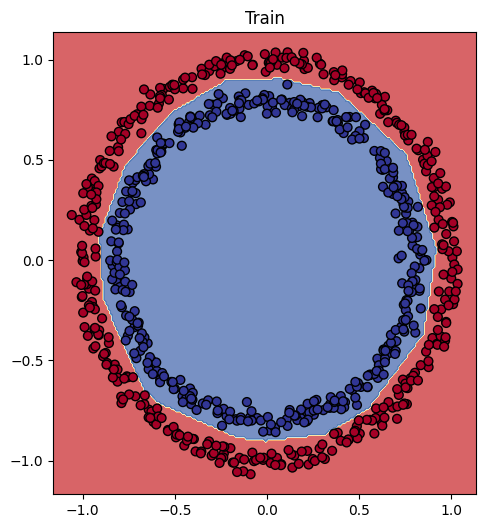

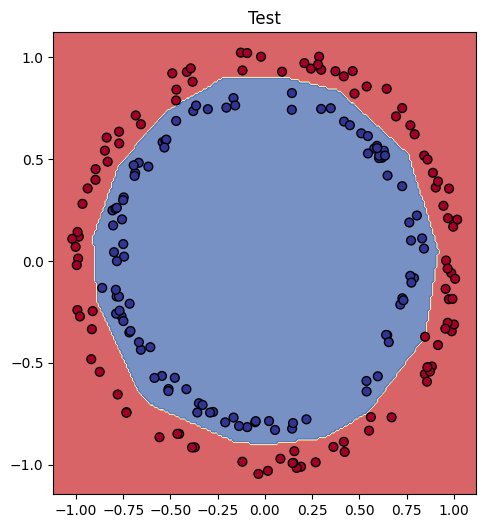

In [10]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model, x_train, y_train)

plt.figure(figsize=(12,6))
pl.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model, x_test, y_test)

## Plotting Loss (Training) Curve

Text(0.5, 1.0, 'Model Loss Curve')

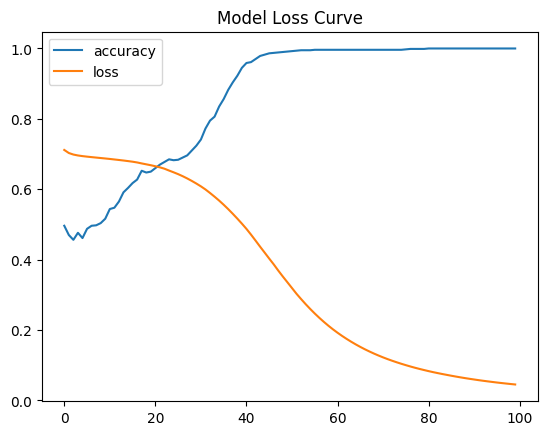

In [11]:
pd.DataFrame(history.history).plot()
plt.title("Model Loss Curve")

## Model Prediction

In [12]:
model.predict(x=x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step


array([[0.969028  ],
       [0.99768925],
       [0.96295035],
       [0.9878457 ],
       [0.1840131 ],
       [0.03011282],
       [0.9348926 ],
       [0.015782  ],
       [0.9565885 ],
       [0.05123073],
       [0.9178112 ],
       [0.3105087 ],
       [0.96350145],
       [0.9311922 ],
       [0.9911362 ],
       [0.9861312 ],
       [0.9427619 ],
       [0.96523386],
       [0.03905888],
       [0.9604222 ],
       [0.02313994],
       [0.99178517],
       [0.9547871 ],
       [0.9734287 ],
       [0.008383  ],
       [0.9137422 ],
       [0.9759258 ],
       [0.05978834],
       [0.00495126],
       [0.99094814],
       [0.00855536],
       [0.98762923],
       [0.97925454],
       [0.00697223],
       [0.15077388],
       [0.9921346 ],
       [0.9709942 ],
       [0.94117093],
       [0.9925742 ],
       [0.99885905],
       [0.9818253 ],
       [0.88437825],
       [0.9786485 ],
       [0.0077684 ],
       [0.9982703 ],
       [0.9257799 ],
       [0.94056964],
       [0.009

## Confusion Matrix

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


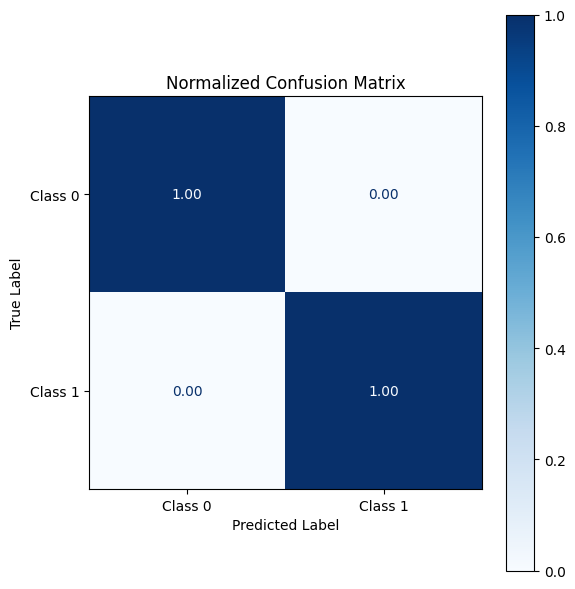

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(
    x_test,
    y_test,
    model,
    class_names=None,
    normalize=True,
    figsize=(6, 6)
):
    # Predict
    y_pred = model.predict(x_test)

    # Convert predictions to class labels
    if y_pred.shape[-1] == 1:
        y_pred = tf.round(y_pred).numpy().astype(int).ravel()
    else:
        y_pred = np.argmax(y_pred, axis=1)

    y_test = y_test.ravel()

    # Auto-generate class names if not provided
    if class_names is None:
        num_classes = len(np.unique(y_test))
        class_names = [f"Class {i}" for i in range(num_classes)]

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Normalize
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        title = "Normalized Confusion Matrix"
        fmt = ".2f"
    else:
        title = "Confusion Matrix"
        fmt = "d"

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(
        cmap="Blues",
        values_format=fmt,
        ax=ax,
        colorbar=True
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(x_test, y_test, model)

---

# Experimenting new model using callback to detect the ideal learning rate

In [14]:
tf.random.set_seed(42)

# Model

# Building Model
callback_model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compiling Model
callback_model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                       optimizer=tf.keras.optimizers.Adam(),
                       metrics=["accuracy"])

# Learning Rate Callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10 **(epoch/20))

# Fitting Model
history_callback = callback_model.fit(x_train, y_train, epochs=100, callbacks=[lr_scheduler])

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5088 - loss: 0.7044 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5063 - loss: 0.7039 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5038 - loss: 0.7034 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4988 - loss: 0.7029 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5038 - loss: 0.7023 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5063 - loss: 0.7017 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5063 - loss: 0.7011 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5038 - loss: 0.7005 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5050 - loss: 0.6999 - learning

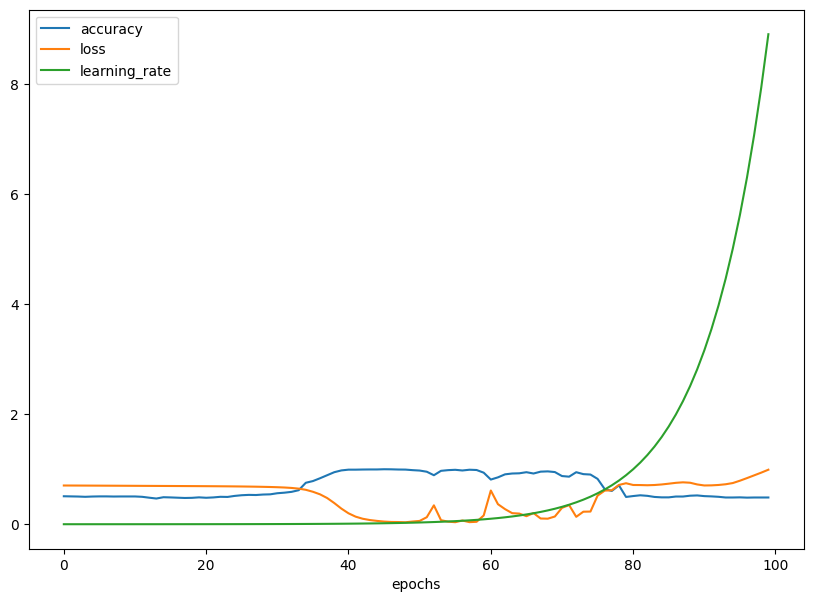

In [15]:
# Checkout the history
pd.DataFrame(history_callback.history).plot(figsize=(10,7), xlabel="epochs");

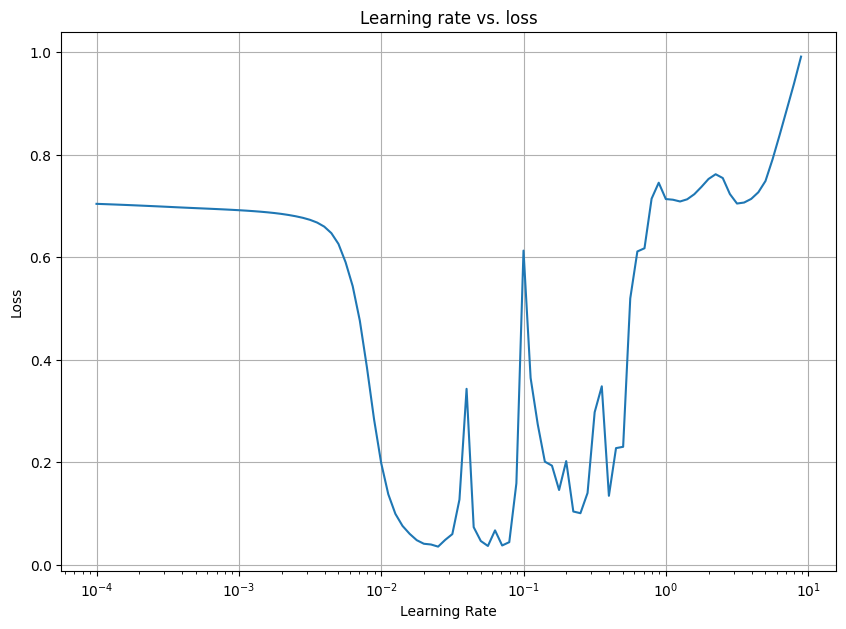

In [16]:
# Plot the learning rate versus the loss
def plot_loss_curve_via_lr(model_history):
    """
    Plot loss vs learning rate using a learning-rate schedule matching the
    number of epochs in model_history.
    """
    losses = model_history.history.get("loss")
    if losses is None:
        raise ValueError("model_history has no 'loss' key")
    n = len(losses)
    lrs = 1e-4 * (10 ** (np.arange(n) / 20))
    plt.figure(figsize=(10, 7))
    plt.semilogx(lrs, losses)
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.title("Learning rate vs. loss")
    plt.grid(True)
    plt.show()

plot_loss_curve_via_lr(history_callback)

In [17]:
import numpy as np

def find_ideal_lr(model_history, skip_begin=10, skip_end=5):
    """
    Find ideal learning rate from model_history.loss by matching the lr array
    length to the number of recorded epochs and returning the lr at the
    steepest descent (after trimming).
    """
    losses = model_history.history.get("loss")
    if losses is None:
        raise ValueError("model_history has no 'loss' key")
    losses = np.array(losses)
    n = len(losses)
    if n <= (skip_begin + skip_end):
        raise ValueError("Not enough epochs for the given skip_begin/skip_end")

    lrs = 1e-4 * (10 ** (np.arange(n) / 20))

    # Smooth losses a bit (use smaller window for short histories)
    window = min(5, n)
    losses_smooth = np.convolve(losses, np.ones(window) / window, mode='same')

    # gradient w.r.t log10(lr)
    log_lrs = np.log10(lrs)
    gradients = np.gradient(losses_smooth, log_lrs)

    # trim unstable regions
    gradients_trim = gradients[skip_begin:-skip_end]
    lrs_trim = lrs[skip_begin:-skip_end]

    ideal_lr = lrs_trim[np.argmin(gradients_trim)]
    return ideal_lr

In [18]:
ideal_lr = find_ideal_lr(history_callback)
print("Ideal learning rate:", ideal_lr)

Ideal learning rate: 0.007943282347242814


## Retrain using the Ideal learning rate

In [19]:
tf.random.set_seed(42)

# build model
model_lr = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# compile using the modern argument name
model_lr.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=ideal_lr),
    metrics=["accuracy"]
)

# fit and capture the History object
history_lr = model_lr.fit(x_train, y_train, epochs=100, verbose=1)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4750 - loss: 0.7001
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.6913
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5200 - loss: 0.6865
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5275 - loss: 0.6821
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5437 - loss: 0.6774
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5575 - loss: 0.6712
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5975 - loss: 0.6553
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6162 - loss: 0.6351
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7212 - loss: 0.6016
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8525 - loss: 0.5510
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8487 - loss: 0.5030
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy

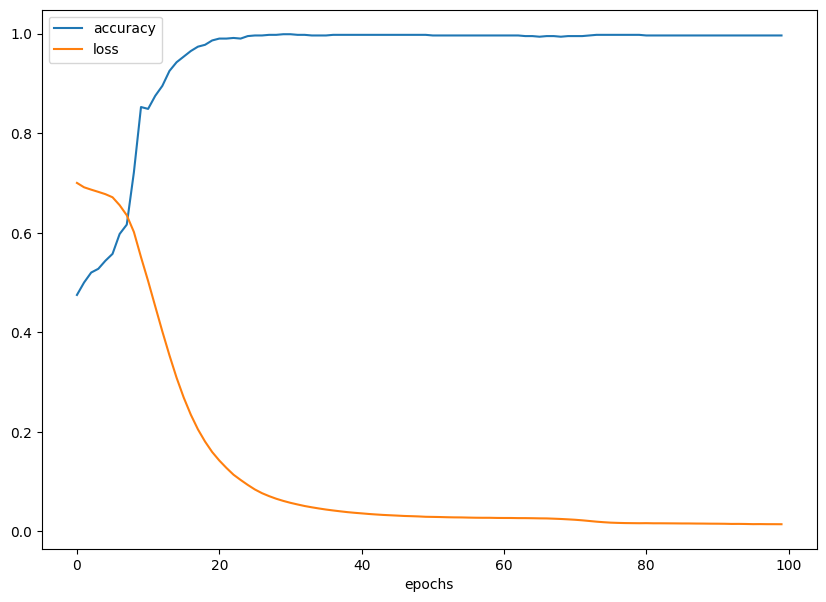

In [20]:
pd.DataFrame(history_lr.history).plot(figsize=(10, 7))
plt.xlabel("epochs")
plt.show()

---

# Practice On Real Dataset
- fashion tensorflow classification dataset

In [21]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [22]:
# Normalization [data will be between (0,1  )]
train_data = train_data / 255.0
test_data = test_data / 255.0

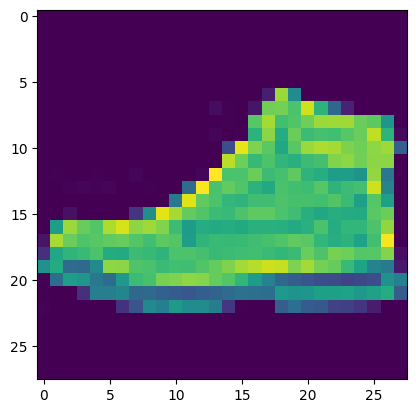

In [23]:
# review sample
plt.imshow(train_data[89])

In [24]:
# class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# How many classes are there (this'll be our output shape)?
len(class_names)

10

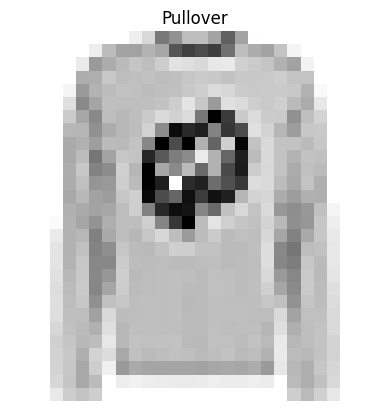

In [25]:
# plot examples with label names
index_of_choice = 123
plt.imshow(train_data[index_of_choice], cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])
plt.axis("off")
plt.show()

In [26]:
# data shape
train_data.shape, train_labels.shape, test_data.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [27]:
# Model

tf.random.set_seed(42)

# building model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# compile model
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10 **(epoch/20))

# fit model
history = model.fit(train_data, train_labels, epochs=40, validation_data=(test_data, test_labels), callbacks=[lr_scheduler])

/home/makrious/.local/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40


2026-01-20 01:45:07.018405: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_130', 4 bytes spill stores, 4 bytes spill loads

2026-01-20 01:45:08.150951: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_130', 12 bytes spill stores, 12 bytes spill loads



1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - accuracy: 0.7753 - loss: 0.6822 - val_accuracy: 0.8302 - val_loss: 0.4963 - learning_rate: 1.0000e-04
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8476 - loss: 0.4426 - val_accuracy: 0.8458 - val_loss: 0.4424 - learning_rate: 1.1220e-04
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8618 - loss: 0.3992 - val_accuracy: 0.8555 - val_loss: 0.4161 - learning_rate: 1.2589e-04
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8701 - loss: 0.3727 - val_accuracy: 0.8608 - val_loss: 0.3986 - learning_rate: 1.4125e-04
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8761 - loss: 0.3528 - val_accuracy: 0.8621 - val_loss: 0.3870 - learning_rate: 1.5849e-04
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8801 - loss: 0.3369 - val_accuracy: 0.8646 - val_loss: 0.3776 - learning_rate: 1.7783e-04
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step

In [28]:
# model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

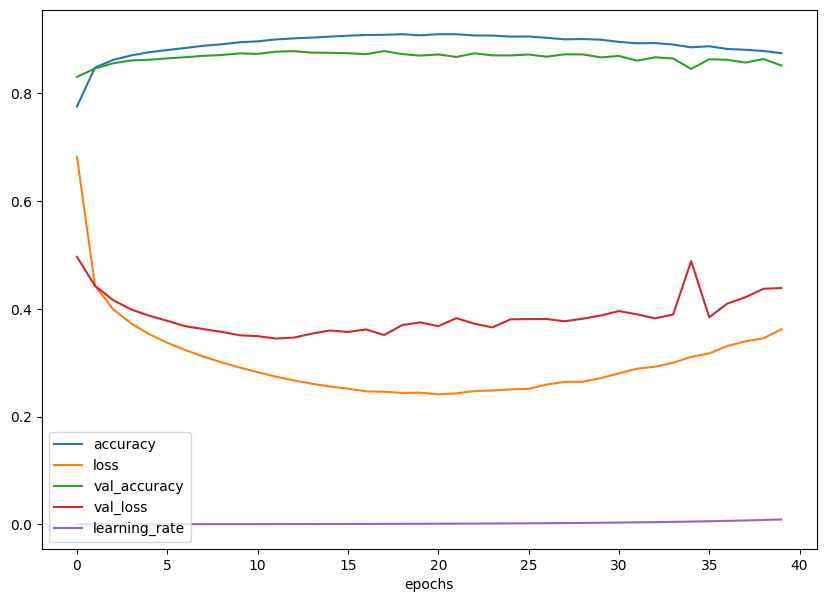

In [29]:
# plotting loss and accuracy curves
pd.DataFrame(history.history).plot(figsize=(10, 7))
plt.xlabel("epochs")
plt.show()

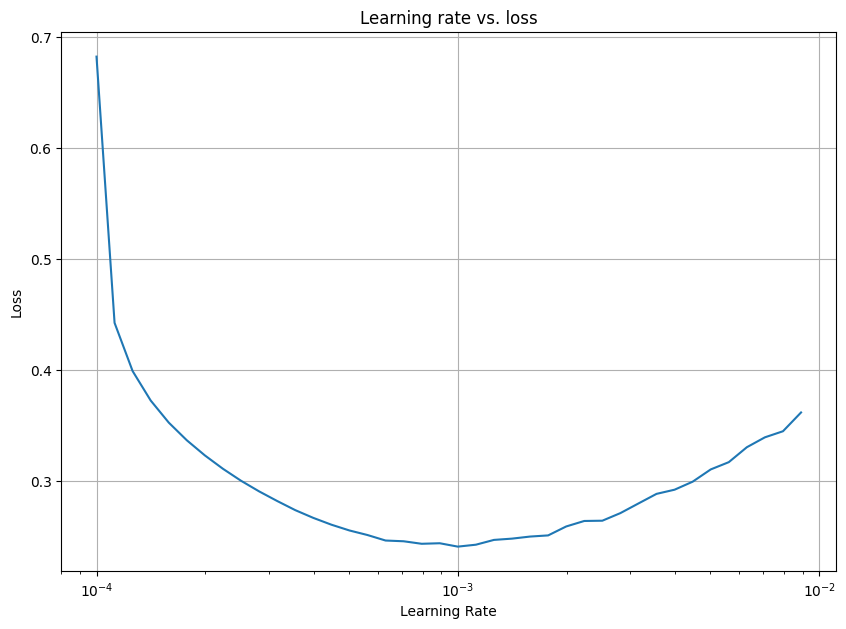

In [30]:
# Plot the learning rate versus the loss
plot_loss_curve_via_lr(history)

In [31]:
# ideal learning rate
ideal_lr = find_ideal_lr(history)
print("Ideal learning rate:", ideal_lr)

Ideal learning rate: 0.000316227766016838


In [33]:
# retrain a model using the ideal learning rate

tf.random.set_seed(42)

# building model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# compile model
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=ideal_lr),
    metrics=["accuracy"]
)

# fit model
history = model.fit(train_data, train_labels, epochs=40, validation_data=(test_data, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.8117 - loss: 0.5494 - val_accuracy: 0.8425 - val_loss: 0.4405
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8627 - loss: 0.3879 - val_accuracy: 0.8529 - val_loss: 0.4027
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8750 - loss: 0.3476 - val_accuracy: 0.8601 - val_loss: 0.3821
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8828 - loss: 0.3221 - val_accuracy: 0.8660 - val_loss: 0.3696
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8892 - loss: 0.3032 - val_accuracy: 0.8694 - val_loss: 0.3632
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8944 - loss: 0.2878 - val_accuracy: 0.8717 - val_loss: 0.3559
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8997 - loss: 0.2744 - val_accuracy: 0.8745 - val_loss: 0.3500
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9034 - loss

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


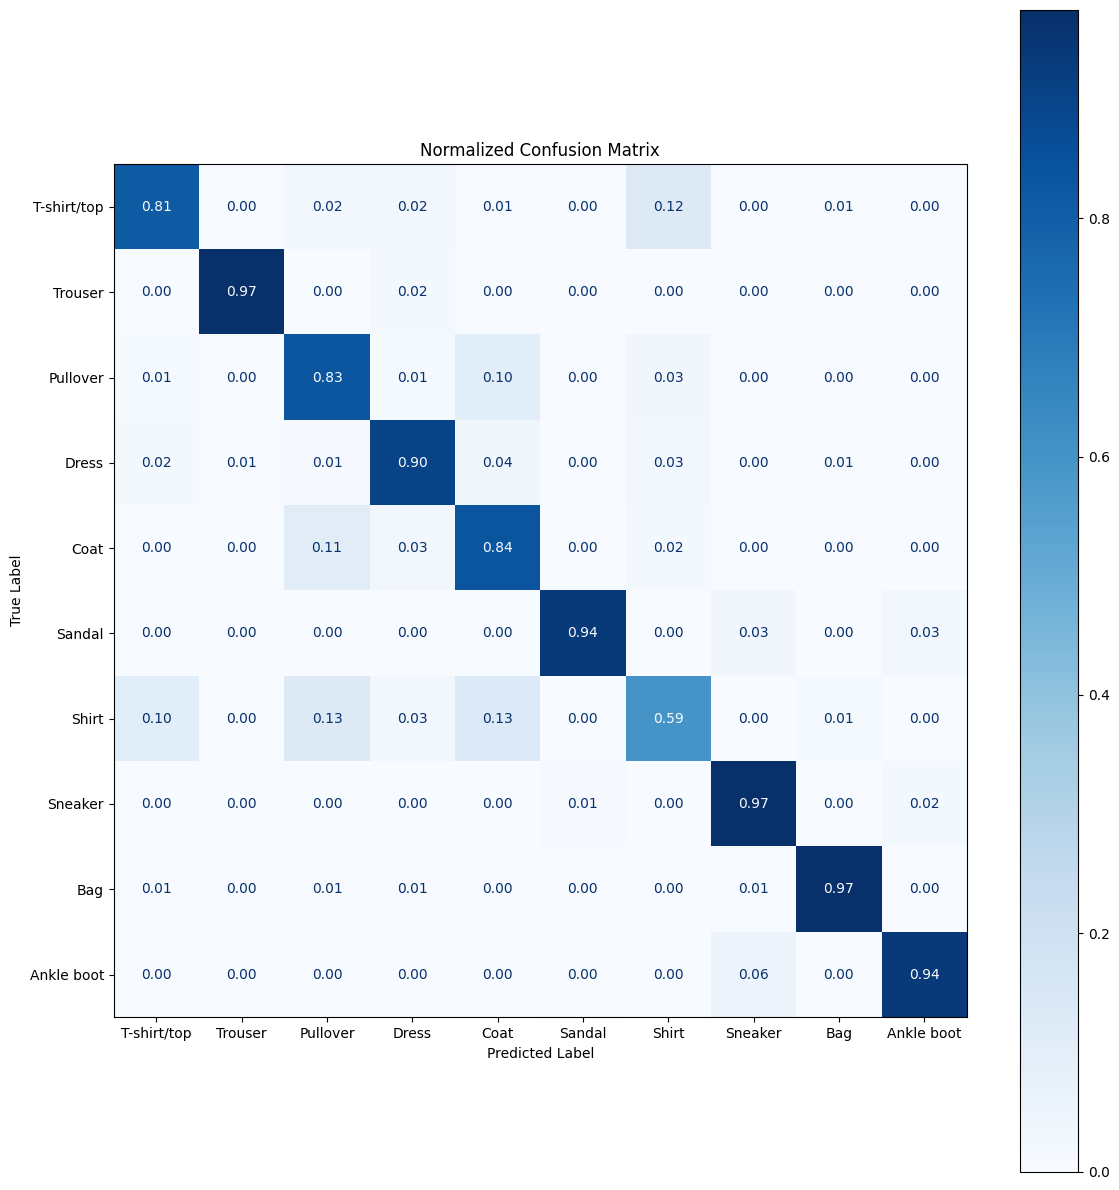

In [35]:
# Confusion Matrix
plot_confusion_matrix(test_data, test_labels, model, class_names=class_names, figsize=(12, 12))

---